# include code files

In [1]:
pathtosrc="../src";

### for the PL Integration methods

In [2]:
include(pathtosrc*"/header/PLIntegration2D/PLIntegration2D.jl");

### my definitions of the setup

In [3]:
# include("../src/header/includes.jl"); # at some point I could put all the includes in here

In [4]:
using Sobol
using NLsolve
using QuadGK
using LinearAlgebra
using Integrals
using FiniteDiff
using StaticArrays
using Contour
using Peaks

In [7]:
include(pathtosrc*"/header/PLIntegration2D/utils.jl")

In [8]:
include(pathtosrc*"/header/beams.jl");

In [13]:
include(pathtosrc*"/header/constants-units.jl");
include(pathtosrc*"/header/saddles.jl");
include(pathtosrc*"/header/Beams/BeamMono.jl")
include(pathtosrc*"/header/Beams/BeamTC.jl")
include(pathtosrc*"/header/Beams/BeamOTC.jl");
include(pathtosrc*"/header/equations.jl");
include(pathtosrc*"/header/harmonic-response.jl");

In [10]:
using CairoMakie # for plotting

# laser field definition

I have implemented the field definitions I usually use in separate 'Beam' classes (`struct`s in julia). You can check their definition in the respective source code files. For short: `BeamOTC` is a orthogonally polarised two-colour field ($r \omega$ + $s \omega$), `BeamTC` is co-linearly polarised, with `BeamBETC` as a convenience constructor for equal ellipticities, `BeamMono` is a monochromatic field.

Define your driving laser field with all the relevant parameters, like e.g. this:

In [14]:
beam0 = BeamBETC(Intensity1 = 3e14, Intensity2 = 0., lambda=800, r=1, s=2, epsilon = 0., phi = 0.) # Ankas setup, monochromatic

BeamTC(0.09258200997725514, 0.0, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 0.0)

In [15]:
beam1 = BeamBETC(Intensity1 = 0.92e14, Intensity2 = 0.092e14, lambda=1030, r=1, s=2, epsilon = 0., phi = 0.678) # random other setup

BeamTC(0.05126959555693246, 0.01621286966755555, 0.04422487690455352, 0.08844975380910704, 0.0, 0.0, 0.678)

### plotting the field shape

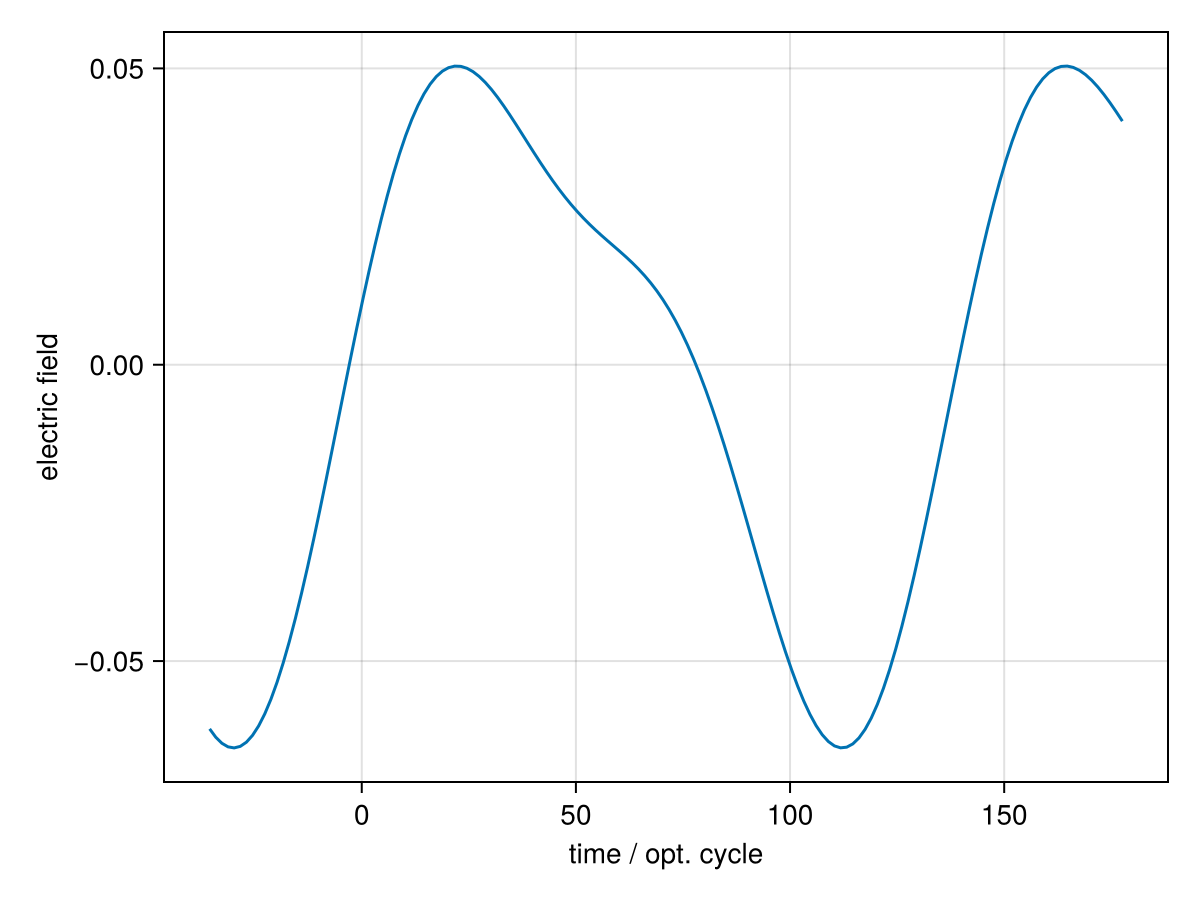

In [16]:
let # local scope block
   
    TC = TCycle(beam1) # 1 optical cycle = 2π/ω
    times = range(-0.25TC, stop = 1.25*TC, length = 150)
    
    efield = [E(beam1)(t)[1] for t in times]
    
    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "electric field"
    ) 
    
    lines!(ax, times, efield)

    f
end

### convenience function to make different beams

just as an example, if you were interested in how the HHG spectrum of a colinear two-colour field depends on the relative intensity of the two components, you could define yourself a function like this:

In [83]:
function beam_R(R::Number)
    ### ω-2ω, linearly polarised, no phase shift
    λ = 1030 # fundamental wavelength in nm
    I_total = 0.92e14;
    
    return BeamBETC(Intensity1 = I_total, Intensity2 = R/(1-R)*I_total,
        lambda=λ, r = 1, s = 2, epsilon = 0., phi = 0.)
    
end

beam_R (generic function with 1 method)

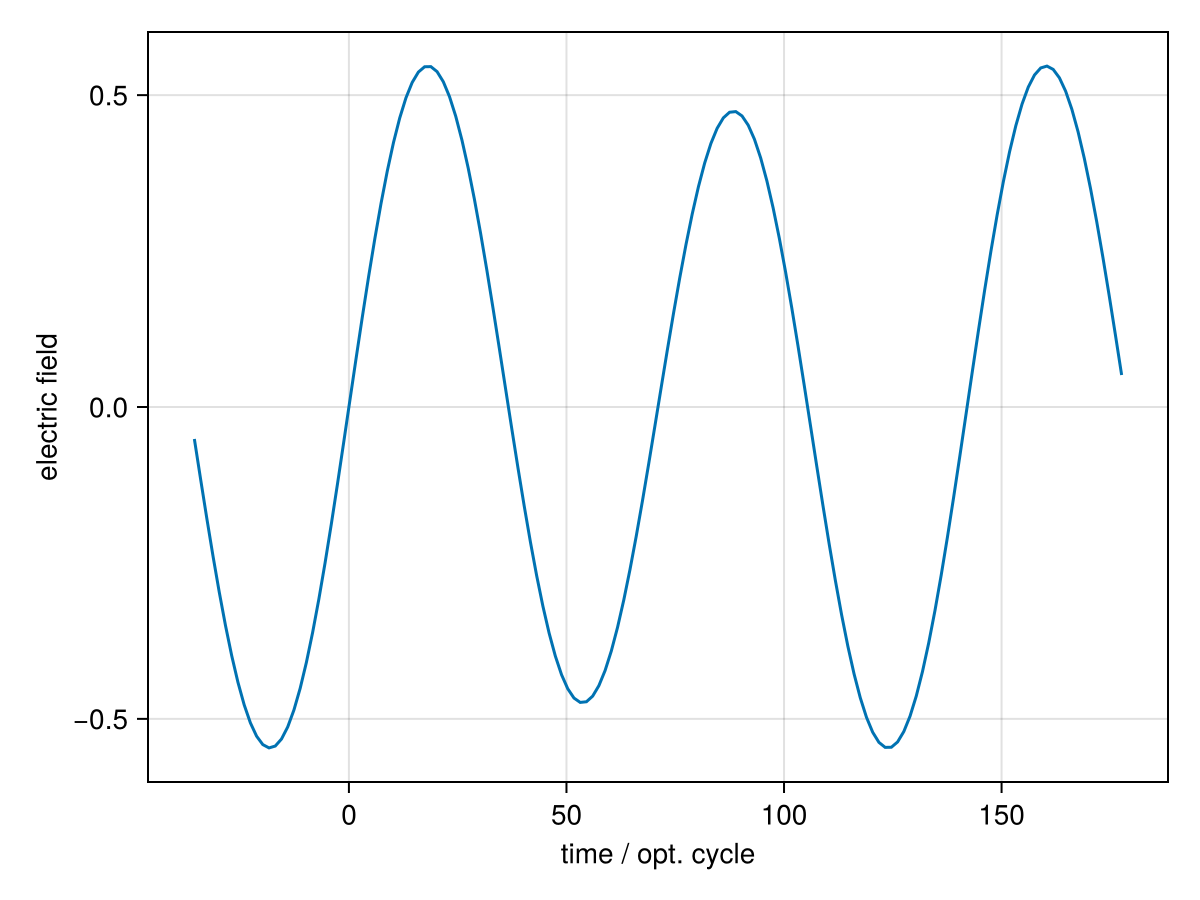

In [84]:
let # local scope block
    beam = beam_R(0.99)
    
    TC = TCycle(beam) # 1 optical cycle = 2π/ω
    times = range(-0.25TC, stop = 1.25*TC, length = 150)

    efield = [E(beam)(t)[1] for t in times]

    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "electric field"
    ) 

    lines!(ax, times, efield)

    f
end

# target

This code is for hydrogenic targets only, and we're working within the SFA, so all we use to describe the target is its ionisation potential `Ip`, in atomic units.

In [17]:
const Ip = IpAU(15.7596) # Argon gas target, we will keep this constant

0.5791543250255408

In case you want to look at the classical solutions you can set $I_p = 0$.

In [14]:
const Ip_class = 0.0;

# using PL integration methods for the HHG dipole

In order to use any of the integration functionalities, we will have to specify the _phase function_ in terms of the two arguments. In our case this phase function is the semi-classical action as a function of ionisation time $t_i$ and $t_r$: $S(t_i, t_r)$. This action depends on the parameter of the field (e.g. its intensity, fundamental wavelength, if there are multiple components and how they are related to each other) as well as on the ionisation potential $I_p$ and the harmonic order $q$. For the deformation of the integration contour, however, these are only 'external parameters' and all the fancy integration functions don't need to know about them. 

## using the saddle points

### finding saddle points

In [112]:
### technically we're just doing this:
let
    q = 25.
    b = beam1

    ### simple example
    guess = [30., 10., 120., 20.] # real(ti), imag(ti), real(tr), imag(tr)
    function speqs!(F, x)
        F[1:2] .= reim(dS_dti(b,Ip,q,x[1]+x[2]*im,x[3]+x[4]*im))
        F[3:4] .= reim(dS_dtr(b,Ip,q,x[1]+x[2]*im,x[3]+x[4]*im))
    end

    nlsolve(speqs!, guess)   
end

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [30.0, 10.0, 120.0, 20.0]
 * Zero: [33.549306642137886, -28.37872342746963, 112.30501938608673, 3.7436862562081963]
 * Inf-norm of residuals: 0.000000
 * Iterations: 21
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 18
 * Jacobian Calls (df/dx): 12

...but using a seeded grid of initial guesses (where we only give the min/max values of the ionisation (`ti`) and travel time (`tt`), and then filter out duplicates etc. Also, we're saving the solutions as a object of class `Saddle` with the fields `q` (harmonic order), `ti` (ionisation time), `tr` (recombination time) and `p` (stationary momentum).

In [18]:
let
    q = 25.
    b = beam1

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    ### define this 'phase function' as a function of two arguments (ionisation and recombination time)
#     action(ti, tr) = -im*S(b, Ip, ti, tr, q)
#     action_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
#     action_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
    
    action, action_grad, action_hessian = action_functions(b, Ip, q)
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
#         ti = tvec[1]; tr = tvec[2]
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    
    
    
    ### iterating over fancy seeded grid, keeping only reasonable solutions, saving them as Sadddle object
    saddles = find_saddles_sobol(q; b = b, Ip = Ip, ti_cd = ComplexDomain(timin+0im, timax+30im), tr_cd = ComplexDomain(timin+ttmin-30im, timax+ttmax+30im))

    ### determining whether they are relevant
    for s in saddles
        rel = check_contribution(action, action_grad, action_hessian, s.ti, s.tr)
        print(s)
        println("   => relevant: ", rel)
#         println()
    end
end

ti: 29.49 + 20.86im, tr: 156.07 + 0.59im, q25.0   => relevant: true
ti: 29.81 + 22.18im, tr: 218.58 + 15.21im, q25.0   => relevant: true
ti: 31.04 + 20.54im, tr: 220.35 - 14.79im, q25.0   => relevant: false
ti: 33.55 + 28.38im, tr: 112.31 - 3.74im, q25.0   => relevant: true
ti: 111.27 + 14.77im, tr: 271.64 - 0.07im, q25.0   => relevant: true
ti: 111.37 + 14.78im, tr: 232.6 - 0.06im, q25.0   => relevant: true
ti: 120.67 + 17.61im, tr: 173.61 - 2.69im, q25.0   => relevant: true


### adding up the contributions of relevant saddle points

In [19]:
let
    q = 29.
    b = beam1

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
    S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
    S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
    S_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
#         ti = tvec[1]; tr = tvec[2]
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    
    ### iterating over fancy seeded grid, keeping only reasonable solutions, saving them as Sadddle object
    saddles = find_saddles_sobol(q; b = b, Ip = Ip,
        ti_cd = ComplexDomain(timin+0im, timax+30im),
        tr_cd = ComplexDomain(timin+ttmin-30im, timax+ttmax+30im))
    
    int_spm = zeros(ComplexF64,2) # sum over gaussian contributions
    int_sdt = zeros(ComplexF64,2) # sum over integrating the attached thimbles
    
    ### determining whether they are relevant
    for s in saddles
        rel = check_contribution(S_f, S_grad,S_hessian,s.ti, s.tr)
        if rel
            println(s)
            int_spm_s = saddles_gaussian_contribution(S_f, S_hessian, s.ti, s.tr, prefactor = prefactor)
            int_spm .+= int_spm_s
            
            int_sdt_s = integrate_SD_thimble(S_f, S_grad, S_hessian, s.ti, s.tr, prefactor=prefactor)
            int_sdt .+= int_sdt_s

            @show int_spm_s
            @show int_sdt_s
        end
        println()
    end
    @show int_spm
    @show int_sdt
end;

ti: 29.76 + 22.55im, tr: 220.48 + 19.69im, q29.0
int_spm_s = ComplexF64[-1.925668788170115e-9 + 8.796151084485859e-9im, 0.0 + 0.0im]
int_sdt_s = ComplexF64[8.39439931735662e-9 + 1.628586367956813e-9im, 0.0 + 0.0im]

ti: 29.83 + 21.06im, tr: 152.99 + 0.69im, q29.0
int_spm_s = ComplexF64[3.367413676657625e-7 - 2.6060024477870497e-6im, 0.0 - 0.0im]
int_sdt_s = ComplexF64[2.57087076158686e-6 + 4.772088164358499e-7im, 0.0 + 0.0im]

ti: 30.61 + 21.46im, tr: 266.7 - 0.46im, q29.0
int_spm_s = ComplexF64[8.13661172552204e-7 - 9.667040152497154e-8im, 0.0 + 0.0im]
int_sdt_s = ComplexF64[-1.288889816148985e-7 - 8.028564625675032e-7im, 0.0 + 0.0im]


ti: 33.48 + 27.89im, tr: 115.38 - 3.52im, q29.0
int_spm_s = ComplexF64[-3.343457236063945e-8 + 7.666117323522975e-9im, 0.0 + 0.0im]
int_sdt_s = ComplexF64[8.434547914639041e-9 + 3.281216767672455e-8im, 0.0 + 0.0im]


ti: 111.86 + 15.17im, tr: 279.35 + 5.43im, q29.0
int_spm_s = ComplexF64[1.3976937291311691e-5 - 2.7206884728001042e-5im, -0.0 + 0.0im]
in

## integrating the flowed integration path

You'll need to specify the driving laser field (the `beam`), the target (via `Ip`), and then the time limits for the integration, here in terms of ionisation (`ti`) and travel (=excursion time, `tt`) time.

In [105]:
let
    q = 29.
    b = beam1
    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
    S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
    S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
    
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
#         ti = tvec[1]; tr = tvec[2]
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    

    integrate_flowed_path(S_f, S_grad, timin, timax, ttmin, ttmax,
        print_message=false, prefactor=prefactor, Nflow=20, maxNsimplices=5000)

    
end

(ComplexF64[-0.00014151535150042094 + 1.1265647427626496e-5im, 0.0 + 0.0im], 1024)

### explanations

There's a bunch of arguments, here's a preliminary very brief explanation (and their default) of what they do:
- `Nflow`= 50. For how long to deform the integration contour. Higher --> takes longer
- `Δinit` = 10. How fine to chop up the integration contour in the beginning. Smaller --> takes longer
- `gradnthreshold` = 0.5. Just ignore it.
- `flowstepfactor` = 2. How fast to deform the integration contour. Higher --> faster, maybe less accurate.
- `subdividethreshold` = 8. How fine to chop up the integration contour, wants to be 4 * `flowstepfactor`.
- `h_threshold` = -150. Where to terminate the integration contour ( ~ Consider $e^{h_\mathrm{threshold}}$ as zero)
- `maxNsimplices` = 5000. Maximum number of pieces of integration contour. If you consider a really large domain you could increase this.
- `integral_accuracy` = 1e-7. For two subsequent steps of the domain deformation the integral doesn't change more than this, then stop.
- `integral_rel_error` = 0.05. For two subsequent steps of the domain deformation the relative integral doesn't change more than this, then stop.
- `print_message` = true. Print a message why the deformation of the integration contour was stopped.

## calculate the full spectrum with the various methods

### preliminary considerations

Before calculating the spectrum, it makes sense to check which harmonic orders to expect (roughly).
The minimum harmonic order ("threshold harmonic") is given by $I_p/\omega$, so e.g.

In [97]:
Ip/get_omega(1030) # 1030 nm fundamental wavelength

13.095668446414814

For the maximum harmonic order you can calculate the classical harmonic cutoff a la $I_p + 3.17 U_p$, for example:

In [98]:
(Ip + 3.17*get_Up(beam1))/get_omega(1030)

37.78123056034171

... and then I usually calculate the spectrum for some ten orders more...

### example for a monochromatic driving field

In [20]:
q_values = range(15., stop = 45., step = 1.);

I'm creating a dictionary where I can look up the harmonic orders. Feel free to do it differently and e.g. write the dipoles into an array or whatever.

In [21]:
dipoles_SPM = let
    dict = Dict{Number, Vector{ComplexF64}}()

    b = beam1

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    for q in q_values
        ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
        S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
        S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
        S_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
        function prefactor(ti,tr)
            ### eq. 5 from Emilio's thc paper
            ps = p_stationary(b, ti, tr)
            dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)

            fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
            traveltime = tr - ti

            prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
            prefactor_const *= fontaine_SR_m0

            return prefactor_const * dip_r
        end

        ### iterating over fancy seeded grid, keeping only reasonable solutions, saving them as Sadddle object
        saddles = find_saddles_sobol(q; b = b, Ip = Ip,
            ti_cd = ComplexDomain(timin+0im, timax+30im),
            tr_cd = ComplexDomain(timin+ttmin-30im, timax+ttmax+30im))

        int_spm = zeros(ComplexF64,2) # sum over gaussian contributions

        ### determining whether they are relevant
        for s in saddles
            rel = check_contribution(S_f, S_grad, S_hessian,s.ti, s.tr)
            if rel
                int_spm_s = saddles_gaussian_contribution(S_f, S_hessian, s.ti, s.tr, prefactor = prefactor)
                int_spm .+= int_spm_s
            end
        end
        dict[q] = int_spm
    end
    dict
end;

In [22]:
dipoles_SDT = let
    dict = Dict{Number, Vector{ComplexF64}}()

    b = beam1

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    for q in q_values
        ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
        S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
        S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
        S_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
        function prefactor(ti,tr)
            ### eq. 5 from Emilio's thc paper
            ps = p_stationary(b, ti, tr)
            dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)

            fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
            traveltime = tr - ti

            prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
            prefactor_const *= fontaine_SR_m0

            return prefactor_const * dip_r
        end

        ### iterating over fancy seeded grid, keeping only reasonable solutions, saving them as Sadddle object
        saddles = find_saddles_sobol(q; b = b, Ip = Ip,
            ti_cd = ComplexDomain(timin+0im, timax+30im),
            tr_cd = ComplexDomain(timin+ttmin-30im, timax+ttmax+30im))

        int_sdt = zeros(ComplexF64,2) # sum over gaussian contributions

        ### determining whether they are relevant
        for s in saddles
            rel = check_contribution(S_f, S_grad, S_hessian,s.ti, s.tr)
            if rel
                int_sdt_s = integrate_SD_thimble(S_f, S_grad, S_hessian, s.ti, s.tr, prefactor=prefactor,
                    flowstepfactor=5., subdividethreshold=1.2)
                int_sdt .+= int_sdt_s
            end
        end
        dict[q] = int_sdt
    end
    dict
end;

In [ ]:
dipoles_FIP = let
    dict = Dict{Number, Vector{ComplexF64}}()

    b = beam1

    timin, timax = (0., 1.) .* TCycle(b)
    ttmin, ttmax = (0.3, 1.) .* TCycle(b)
    
    for q in q_values
        ### define this 'phase function' as a function of two arguments (ionisation and recombiantion time)
        S_f(ti, tr) = -im*S(b, Ip, ti, tr, q)
        S_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
        S_hessian(ti,tr) = my_hessian(b, Ip,q, ti, tr)
        function prefactor(ti,tr)
            ### eq. 5 from Emilio's thc paper
            ps = p_stationary(b, ti, tr)
            dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)

            fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
            traveltime = tr - ti

            prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
            prefactor_const *= fontaine_SR_m0

            return prefactor_const * dip_r
        end
       
        dict[q] = integrate_flowed_path(S_f, S_grad, timin, timax, ttmin, ttmax,
        print_message=false, prefactor=prefactor, Nflow=20, maxNsimplices=5000)[1]

    end
    dict
end;

Calculate the intensitites from the dipole:

In [103]:
intensities_SPM = [harmonic_intensity(beam1, dipoles_SPM[q], q) == 0. ? missing : harmonic_intensity(beam1, dipoles_SPM[q], q) for q in q_values];
intensities_SDT = [harmonic_intensity(beam1, dipoles_SDT[q], q) == 0. ? missing : harmonic_intensity(beam1, dipoles_SDT[q], q) for q in q_values];
intensities_FIP = [harmonic_intensity(beam1, dipoles_FIP[q], q) == 0. ? missing : harmonic_intensity(beam1, dipoles_FIP[q], q) for q in q_values];

And then plot the intensities:

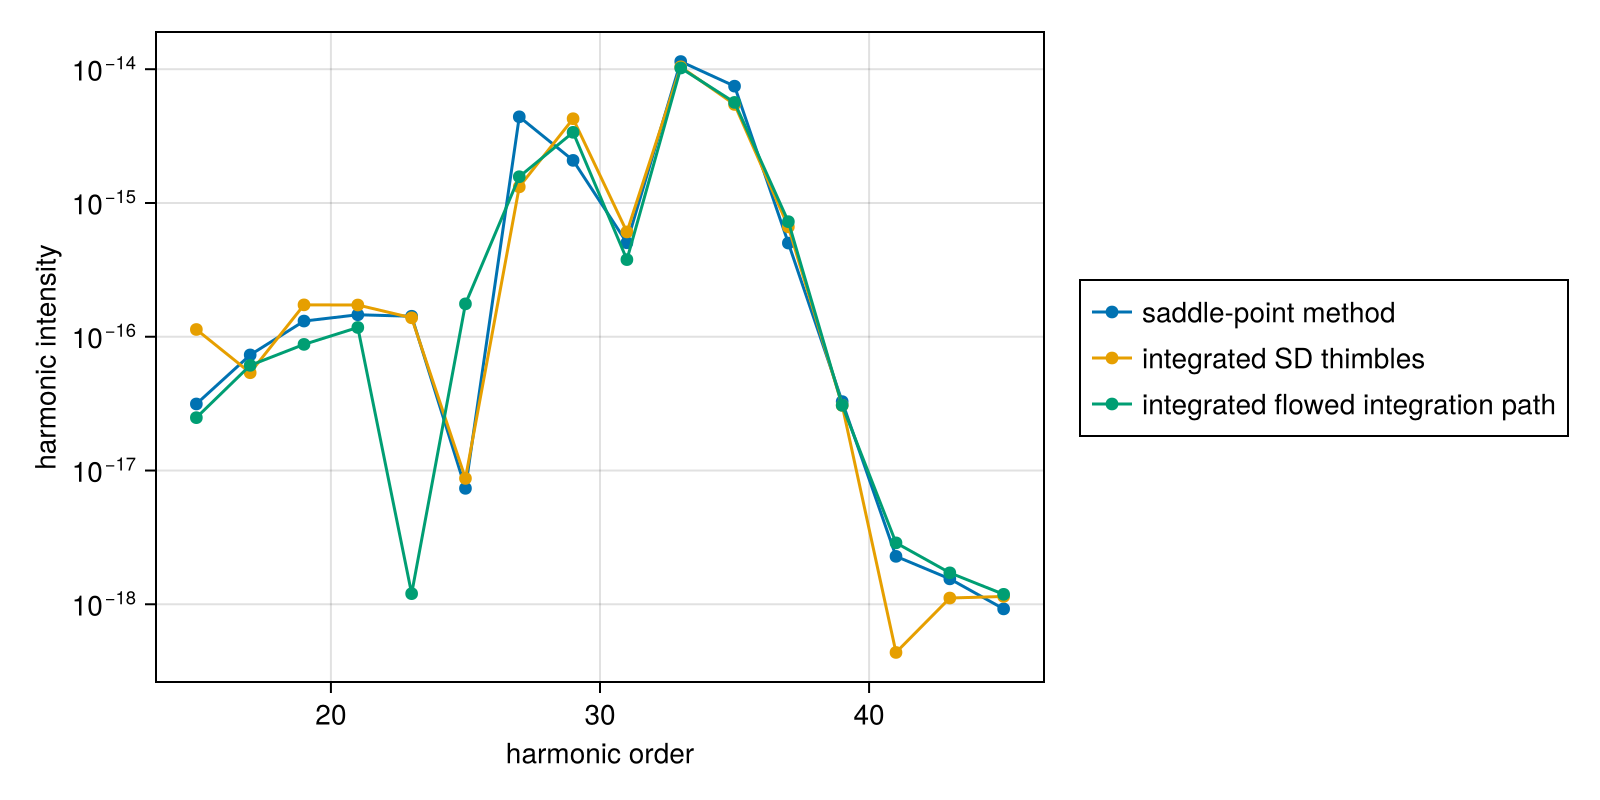

In [104]:
let # local scope block 
    f = Figure(size=(800,400))
    ax = Axis(f[1, 1], 
        yscale = log10, 
        xlabel = "harmonic order", ylabel = "harmonic intensity" ) 
    
#     ylims!(ax, (1e-16,1e-12))

    scatterlines!(ax, q_values[1:2:end], intensities_SPM[1:2:end], label = "saddle-point method")
    scatterlines!(ax, q_values[1:2:end], intensities_SDT[1:2:end], label = "integrated SD thimbles")
    scatterlines!(ax, q_values[1:2:end], intensities_FIP[1:2:end], label = "integrated flowed integration path")

    f[1,2] = Legend(f, ax)
    f
end